In [1]:
import pandas as pd
import scipy.stats
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
from tqdm import tqdm
from geopy.distance import geodesic
from sklearn.preprocessing import TargetEncoder
from concurrent.futures import ThreadPoolExecutor
import itertools
import gc
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('data/cleaned_card_transactions_2025.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98037 entries, 0 to 98036
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Recnum             98037 non-null  int64  
 1   Cardnum            98037 non-null  int64  
 2   Date               98037 non-null  object 
 3   Merchnum           98037 non-null  object 
 4   Merch description  98037 non-null  object 
 5   Merch state        98037 non-null  object 
 6   Merch zip          98037 non-null  object 
 7   Transtype          98037 non-null  object 
 8   Amount             98037 non-null  float64
 9   Fraud              98037 non-null  int64  
 10  amount_okay        98037 non-null  bool   
dtypes: bool(1), float64(1), int64(3), object(6)
memory usage: 7.6+ MB


In [4]:
df['Recnum'] = df['Recnum'].astype(int) # int for chronological sorting
df['Cardnum'] = df['Cardnum'].astype(str)
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d')
df['amount_okay'] = df['amount_okay'].astype(int)
df = df.drop(columns=['Transtype'])

In [5]:
df['DayOfWeek'] = df['Date'].dt.dayofweek

### Entities Creation

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98037 entries, 0 to 98036
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Recnum             98037 non-null  int32         
 1   Cardnum            98037 non-null  object        
 2   Date               98037 non-null  datetime64[ns]
 3   Merchnum           98037 non-null  object        
 4   Merch description  98037 non-null  object        
 5   Merch state        98037 non-null  object        
 6   Merch zip          98037 non-null  object        
 7   Amount             98037 non-null  float64       
 8   Fraud              98037 non-null  int64         
 9   amount_okay        98037 non-null  int32         
 10  DayOfWeek          98037 non-null  int32         
dtypes: datetime64[ns](1), float64(1), int32(3), int64(1), object(5)
memory usage: 7.1+ MB


In [7]:
# Two-way combinations: Card-based
df['card_merch'] = df['Cardnum'] + '_' + df['Merchnum']
df['card_zip'] = df['Cardnum'] + '_' + df['Merch zip']
df['card_state'] = df['Cardnum'] + '_' + df['Merch state']
df['card_merchdesc'] = df['Cardnum'] + '_' + df['Merch description']
df['card_dow'] = df['Cardnum'] + '_' + df['DayOfWeek'].astype(str)

# Two-way combinations: Merchant-based
df['merch_zip'] = df['Merchnum'] + '_' + df['Merch zip']
df['merch_state'] = df['Merchnum'] + '_' + df['Merch state']
df['merchnum_desc'] = df['Merchnum'] + '_' + df['Merch description']
df['merchnum_dow'] = df['Merchnum'] + '_' + df['DayOfWeek'].astype(str)

# Two-way combinations: Location/Description-based
df['state_desc'] = df['Merch state'] + '_' + df['Merch description']
df['merchdesc_dow'] = df['Merch description'] + '_' + df['DayOfWeek'].astype(str)
df['merchdesc_state'] = df['Merch description'] + '_' + df['Merch state']
df['merchdesc_zip'] = df['Merch description'] + '_' + df['Merch zip']

# Three-way combinations: Card + Merchant + Location/Description
df['card_merchnum_desc'] = df['Cardnum'] + '_' + df['Merchnum'] + '_' + df['Merch description']
df['card_merchnum_zip'] = df['Cardnum'] + '_' + df['Merchnum'] + '_' + df['Merch zip']
df['card_merchnum_state'] = df['Cardnum'] + '_' + df['Merchnum'] + '_' + df['Merch state']
df['card_merchdesc_zip'] = df['Cardnum'] + '_' + df['Merch description'] + '_' + df['Merch zip']
df['card_merchdesc_state'] = df['Cardnum'] + '_' + df['Merch description'] + '_' + df['Merch state']

# Three-way combinations: Merchant + Description + Location
df['merchnum_desc_state'] = df['Merchnum'] + '_' + df['Merch description'] + '_' + df['Merch state']
df['merchnum_desc_zip'] = df['Merchnum'] + '_' + df['Merch description'] + '_' + df['Merch zip']

# Zip3-based combinations (these may increase computation time)
df['zip3'] = df['Merch zip'].str[:3]
df['card_zip3'] = df['Cardnum'] + '_' + df['zip3']
df['state_zip'] = df['Merch state'] + '_' + df['Merch zip']
df['merchnum_zip3'] = df['Merchnum'] + '_' + df['zip3']

We are keeping Cardnum and Merchnum as key grouping entities in the following feature engineering. All others are excluded because they are either embedded in the combination entities or is the subject of aggregation (e.g. Amount).

In [8]:
# entity columns for time-based aggregations
entity_cols = [
    'Cardnum', 'Merchnum',
    'card_merch', 'card_zip', 'card_state', 'card_merchdesc', 'card_dow',
    'merch_zip', 'merch_state', 'merchnum_desc', 'merchnum_dow',
    'state_desc', 'merchdesc_dow', 'merchdesc_state', 'merchdesc_zip',
    'card_merchnum_desc', 'card_merchnum_zip', 'card_merchnum_state',
    'card_merchdesc_zip', 'card_merchdesc_state',
    'merchnum_desc_state', 'merchnum_desc_zip',
    'zip3', 'card_zip3', 'state_zip', 'merchnum_zip3'
]

# Filter out entities with low cardinality (<=10 unique values)
entities_to_keep = []
entities_to_remove = []

for entity in entity_cols:
    unique_count = df[entity].nunique()
    status = "REMOVE" if unique_count <= 10 else "KEEP"
    print(f"{entity:30} {unique_count:>8} unique | {status}")
    
    if unique_count <= 10:
        entities_to_remove.append(entity)
    else:
        entities_to_keep.append(entity)

print(f"\nKept {len(entities_to_keep)} entities, removed {len(entities_to_remove)} low-cardinality entities")

Cardnum                            1643 unique | KEEP
Merchnum                          13605 unique | KEEP
card_merch                        40683 unique | KEEP
card_zip                          34236 unique | KEEP
card_state                        16158 unique | KEEP
card_merchdesc                    43669 unique | KEEP
card_dow                           9185 unique | KEEP
merch_zip                         13796 unique | KEEP
merch_state                       13669 unique | KEEP
merchnum_desc                     14588 unique | KEEP
merchnum_dow                      27921 unique | KEEP
state_desc                        13225 unique | KEEP
merchdesc_dow                     27842 unique | KEEP
merchdesc_state                   13225 unique | KEEP
merchdesc_zip                     13467 unique | KEEP
card_merchnum_desc                45861 unique | KEEP
card_merchnum_zip                 40831 unique | KEEP
card_merchnum_state               40712 unique | KEEP
card_merchdesc_zip          

In [9]:
if entities_to_remove:
    df.drop(columns=entities_to_remove, inplace=True)
    print(f"Dropped {len(entities_to_remove)} columns: {entities_to_remove}")

# Update entity list to only include kept entities
entity_cols = entities_to_keep

print(f"dataframe shape: {df.shape}")
print(f"{len(entity_cols)} entities for feature engineering")

dataframe shape: (98037, 35)
26 entities for feature engineering


In [10]:
# Ensure chronological ordering
df = df.sort_values('Recnum').reset_index(drop=True)

### Notes about Data Partitioning

We use an unconventional naming scheme here: 
- training - the data that the model is trained on.
- testing - the data that the model is immediately evaluated on, to inform decisions on model improvements.
- validation - the data that is intentially left out, as a final evaluator of the tuned model.

Then we have a few choices as to how to partition the data.
##### 1. Random Split + K-Fold
*Treats all transactions as independent, ignoring timestamps.*

* Advantage: Maximizes data utility and provides a stable estimate of model variance across subsets.
* Disadvantage: High risk of temporal leakage and entity overfitting. The model may "memorize" specific fraudsters seen in both training and testing, leading to over-optimistic performance.

##### 2. Strict Time-Series Split
*Chronological "Walk-Forward" validation (e.g., Train on Month 1 $\rightarrow$ Test on Month 2).*

* Advantage: Accurately simulates how a model ages as fraud tactics evolve.
* Disadvantage: The initial folds have very little data, which is problematic for fraud detection where the "positive" class (fraud) is already extremely rare. More importantly, since this methods essentially turns it into a forecasting exercise, it may unfairly penalize the model by not allowing it to use the full breadth of historical patterns available at the time of a real-time inference.

##### 3. Hybrid: Historical K-Fold + Out-of-Time (OOT)
*Uses the most recent months as a final "Blind" test, with K-Fold on the remaining history.*

* Advantage: It balances robust training (K-Fold) with a "time-safe" validation set for final sign-off.
* Disadvantage: Requires strict feature engineering discipline. Must ensure that aggregates (e.g., 30-day spend) are calculated using only data available *prior* to each transaction's timestamp to avoid leakage.

It becomes clear that the third choice is the most appropriate for this setting. I will make sure that the aggregates are calculated using only data available prior to each transaction's timestamp.

### Target Encoding

Target encoding converts categorical variables into numeric values based on their relationship with the target variable (Fraud). This helps capture the predictive power of high-cardinality categorical features.
- Evaluated via historical expanding window to strictly avoid future leakage.
- Use smoothing to prevent overfitting on rare categories.
- Unseen categories in test data receive the global mean fraud rate.

In [11]:
# Columns to target encode
col_TE = ['Merch state', 'Merch zip', 'DayOfWeek']

print(f"Columns to encode: {col_TE}")
print(f"\nDataset shape: {df.shape}")

for col in col_TE:
    print(f"{col} cardinality: {df[col].nunique()}")

Columns to encode: ['Merch state', 'Merch zip', 'DayOfWeek']

Dataset shape: (98037, 35)
Merch state cardinality: 55
Merch zip cardinality: 4579
DayOfWeek cardinality: 7


While there is a TargetEncoder package provided by sklearn, it doesn't have the function to be able to evaluate via historical expanding window, which is what we want to avoid data leakage in our setting.

We define a weighting factor as ($w$):

$$w = \frac{n}{n + k}$$

*(Where $n$ is the Total Count and $k$ is the Smoothing Factor)*

The smoothed estimate is:

$$\text{Smoothed Value} = w \cdot (\text{Category Mean}) + (1 - w) \cdot (\text{Global Mean})$$

If we substitute the Category Mean as $\frac{\text{Fraud Count} \mid \text{Category}}{n}$ and simplify the algebra, we arrive at the following formula:

$$\frac{(\text{Fraud Count} \mid \text{Category}) + (\text{Global Mean} \times k)}{n + k}$$

[Merch state] Best Smoothing: 250 (AUC: 0.5891)
[Merch zip] Best Smoothing: 50 (AUC: 0.6322)
[DayOfWeek] Best Smoothing: 1000 (AUC: 0.5517)


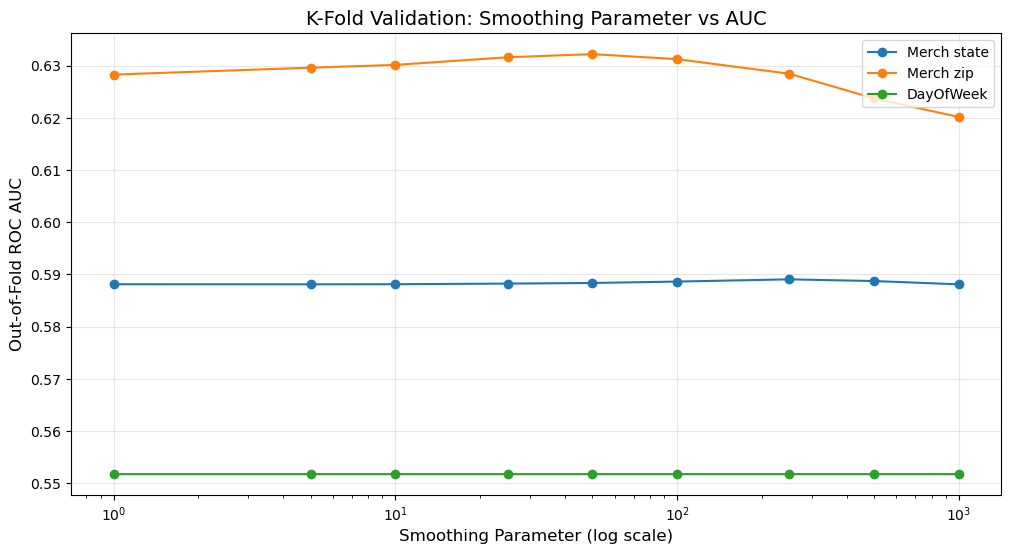

In [12]:
cols_to_tune = ['Merch state', 'Merch zip', 'DayOfWeek']
smoothing_params = [1, 5, 10, 25, 50, 100, 250, 500, 1000]

# Global K-Fold cross validation (Out-of-Fold target encoding)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

plt.figure(figsize=(12, 6))

for col in cols_to_tune:
    cv_auc_scores = []
    
    for s in smoothing_params:
        oof_pred = np.zeros(len(df))
        
        for train_idx, val_idx in kf.split(df):
            train_fold = df.iloc[train_idx]
            val_fold = df.iloc[val_idx]
            
            # Calculate statistics strictly within the training fold
            global_mean = train_fold['Fraud'].mean()
            stats = train_fold.groupby(col)['Fraud'].agg(['sum', 'count'])
            
            # Bayesian smoothed Target Encoding formula
            smoothed_te = (stats['sum'] + global_mean * s) / (stats['count'] + s)
            
            # Map back to the validation fold
            oof_pred[val_idx] = val_fold[col].map(smoothed_te).fillna(global_mean)
            
        # Measure the predictive power (ROC AUC) of the target encoding alone
        auc = roc_auc_score(df['Fraud'], oof_pred)
        cv_auc_scores.append(auc)
        
    # Plot the line for this specific column
    plt.plot(smoothing_params, cv_auc_scores, marker='o', linestyle='-', label=col)
    
    best_s = smoothing_params[np.argmax(cv_auc_scores)]
    best_auc = np.max(cv_auc_scores)
    print(f"[{col}] Best Smoothing: {best_s} (AUC: {best_auc:.4f})")

plt.xscale('log')
plt.xlabel('Smoothing Parameter (log scale)', fontsize=12)
plt.ylabel('Out-of-Fold ROC AUC', fontsize=12)
plt.title('K-Fold Validation: Smoothing Parameter vs AUC', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

As shown above, smoothing matters more for columns with high cardinality.

In [13]:
# Smoothing parameter to limit the influence of rare categories
col_TE = {
    'Merch state': 10, 
    'Merch zip': 50, 
    'DayOfWeek': 10
}

# The following code assumes that the df is ordered by Recnum

for col, smoothing in col_TE.items():
    
    # Historical Expanding Target Encoding for the entire dataset
    # By subtracting the current row's Fraud value from cumsum, we strictly use *prior* historical data.
    cum_fraud = df.groupby(col)['Fraud'].cumsum() - df['Fraud']
    cum_count = df.groupby(col).cumcount()
    
    # Expanding global mean (prior) over the whole dataset to use as a smoothing prior
    global_cum_fraud = df['Fraud'].cumsum() - df['Fraud']
    global_cum_count = np.arange(len(df))
    global_cum_count_safe = np.maximum(global_cum_count, 1) # Prevent division by zero
    global_exp_mean = global_cum_fraud / global_cum_count_safe
    
    # Smoothed expanding mean target encoding calculation
    df[f'{col}_TE'] = (cum_fraud + global_exp_mean * smoothing) / (cum_count + smoothing)
    
    print(f"  Overall mean for {col}_TE: {df[f'{col}_TE'].mean():.4f}")

print(f"\nFinal dataset shape: {df.shape}")

  Overall mean for Merch state_TE: 0.0245
  Overall mean for Merch zip_TE: 0.0255
  Overall mean for DayOfWeek_TE: 0.0249

Final dataset shape: (98037, 38)


### Prepare Dataframes for Time-Based Feature Engineering

In [14]:
# df_main: Main dataframe representing "current" transactions
# df_past: Reference dataframe representing "historical/past" transactions for self-joins
# df_features: Accumulator for all engineered features (starts as copy of df_main)

df_main = df.copy()
df_past = df.copy()
df_features = df.copy()

# Add reference columns to df_past for self-join operations
df_past['past_date'] = df_past['Date']
df_past['past_recnum'] = df_past['Recnum']

### Time-Based Feature Engineering

For each entity, we create:
1. **Days since last transaction**: How many days since this entity was last seen
2. **Transaction frequency**: Count of transactions in various time windows (0, 1, 3, 7, 14, 30, 60 days)
3. **Amount statistics**: Average, max, median, and total amounts per time window
4. **Ratio features**: Current amount relative to historical patterns (actual/avg, actual/max, etc.)

In [15]:
# Time windows for rolling aggregations (in days)
TIME_WINDOWS = [0, 1, 3, 7, 14, 30, 60]

# Collect all new features in a dictionary
new_features = {}

for entity in tqdm(entity_cols, desc="Processing entities"):
    
    # Self-join: current transactions with historical transactions
    merged = pd.merge(
        df_main[['Recnum', 'Date', entity]],
        df_past[['past_recnum', 'past_date', entity, 'Amount']],
        on=entity
    )
    
    # Filter to only past transactions (past_recnum < current Recnum)
    past_txns = merged[merged.Recnum > merged.past_recnum]
    
    # DAYS SINCE LAST TRANSACTION
    last_txn = past_txns.groupby('Recnum')[['Date', 'past_date']].last()
    days_since = (last_txn['Date'] - last_txn['past_date']).dt.days
    
    # For those with no prior transaction, fill with days since 2010-01-01
    new_features[f'{entity}_day_since'] = df_main['Recnum'].map(days_since).fillna(
        (df_main['Date'] - pd.to_datetime('2010-01-01')).dt.days
    )
    
    # ROLLING TIME WINDOW FEATURES
    for days in TIME_WINDOWS:
        # Filter transactions within time window
        window_txns = past_txns[
            past_txns['past_date'] >= (past_txns['Date'] - dt.timedelta(days))
        ][['Recnum', entity, 'Amount']]
        
        # Count of transactions in window
        txn_counts = window_txns.groupby('Recnum')[entity].count()
        new_features[f'{entity}_count_{days}'] = df_main['Recnum'].map(txn_counts)
        
        # Amount aggregations
        amount_agg = window_txns.groupby('Recnum')['Amount'].agg(['mean', 'max', 'median', 'sum'])
        new_features[f'{entity}_avg_{days}'] = df_main['Recnum'].map(amount_agg['mean'])
        new_features[f'{entity}_max_{days}'] = df_main['Recnum'].map(amount_agg['max'])
        new_features[f'{entity}_med_{days}'] = df_main['Recnum'].map(amount_agg['median'])
        new_features[f'{entity}_total_{days}'] = df_main['Recnum'].map(amount_agg['sum'])
        
        # Ratio features: current amount relative to historical patterns
        new_features[f'{entity}_actual/avg_{days}'] = df_main['Amount'] / new_features[f'{entity}_avg_{days}']
        new_features[f'{entity}_actual/max_{days}'] = df_main['Amount'] / new_features[f'{entity}_max_{days}']
        new_features[f'{entity}_actual/med_{days}'] = df_main['Amount'] / new_features[f'{entity}_med_{days}']
        new_features[f'{entity}_actual/total_{days}'] = df_main['Amount'] / new_features[f'{entity}_total_{days}']

Processing entities: 100%|██████████| 26/26 [03:56<00:00,  9.08s/it]


In [16]:
print(f"Features in dictionary so far: {len(new_features)}")

Features in dictionary so far: 1664


### Derived Features from Time-Based Aggregations

1. **Velocity ratios**: Compare short-term activity to longer-term patterns
2. **Velocity-to-recency ratios**: Activity rate normalized by days since last transaction  
3. **Amount variability**: Differences between current and past transaction amounts

In [17]:
# VELOCITY RATIOS: Compare short-term vs long-term activity patterns
SHORT_WINDOWS = [0, 1]
LONG_WINDOWS = [7, 14, 30, 60]

for entity in tqdm(entity_cols, desc="Velocity ratios"):
    for short in SHORT_WINDOWS:
        for long in LONG_WINDOWS:
            # Transaction count velocity: short-term count / long-term count / days
            new_features[f'{entity}_count_{short}_by_{long}'] = \
                new_features[f'{entity}_count_{short}'] / new_features[f'{entity}_count_{long}'] / long
            
            # Amount velocity: short-term total / long-term total / days
            new_features[f'{entity}_total_amount_{short}_by_{long}'] = \
                new_features[f'{entity}_total_{short}'] / new_features[f'{entity}_total_{long}'] / long

# VELOCITY-TO-RECENCY RATIOS: Activity rate normalized by days since last transaction
for entity in tqdm(entity_cols, desc="Velocity-to-recency ratios"):
    for short in SHORT_WINDOWS:
        for long in LONG_WINDOWS:
            new_features[f'{entity}_vdratio_{short}by{long}'] = \
                new_features[f'{entity}_count_{short}_by_{long}'] / (new_features[f'{entity}_day_since'] + 1)

Velocity-to-recency ratios: 100%|██████████| 26/26 [00:00<00:00, 119.81it/s]


In [18]:
# AMOUNT VARIABILITY: Track differences between current and historical transaction amounts
VARIABILITY_WINDOWS = [0, 1, 3, 7, 14, 30]

for entity in tqdm(entity_cols, desc="Amount variability"):
    
    merged = pd.merge(
        df_main[['Recnum', 'Date', entity, 'Amount']],
        df_past[['past_recnum', 'past_date', entity, 'Amount']],
        on=entity,
        suffixes=('_current', '_past')
    )
    
    # only past transactions
    past_txns = merged[merged.Recnum > merged.past_recnum]
    
    for days in VARIABILITY_WINDOWS:
        # filter for transactions within time window
        window_txns = past_txns[
            past_txns['past_date'] >= (past_txns['Date'] - dt.timedelta(days))
        ].copy()
        
        window_txns['amount_diff'] = window_txns['Amount_past'] - window_txns['Amount_current']
        
        variability_agg = window_txns.groupby('Recnum')['amount_diff'].agg(['mean', 'max', 'median'])
        new_features[f'{entity}_variability_avg_{days}'] = df_main['Recnum'].map(variability_agg['mean'])
        new_features[f'{entity}_variability_max_{days}'] = df_main['Recnum'].map(variability_agg['max'])
        new_features[f'{entity}_variability_med_{days}'] = df_main['Recnum'].map(variability_agg['median'])

Amount variability:   0%|          | 0/26 [00:00<?, ?it/s]

Amount variability: 100%|██████████| 26/26 [03:10<00:00,  7.34s/it]


In [19]:
print(f"Features in dictionary so far: {len(new_features)}")

Features in dictionary so far: 2756


The following cross-entity diversity requires a lot of memory, and we are choosing to save the features we have so far to disk to mitigate memory issues.

In [20]:
print(f"Saving {len(new_features)} features to disk...")

temp_df = pd.DataFrame(new_features, index=df_main.index)
temp_df.to_parquet('data/features_batch_before_crossentity.parquet')
new_features = {}
del temp_df
gc.collect()

Saving 2756 features to disk...


0

### Cross-Entity Diversity Features

Track unique counts of one entity within time windows of another entity.
- Example: "How many unique merchants did this card visit in the past 7 days?"
- Captures diversity and breadth of transaction patterns across entities

In [21]:
# CROSS-ENTITY DIVERSITY: Count unique values of one entity within another entity's time windows
DIVERSITY_WINDOWS = [1, 3, 7, 14, 30, 60]

def process_entity_pair(entity_pair):
    """Process one entity pair for all time windows"""
    entity_i, entity_j = entity_pair
    pair_features = {}
    
    merged = pd.merge(
        df_main[['Recnum', 'Date', entity_i]],
        df_past[['past_recnum', 'past_date', entity_i, entity_j]],
        on=entity_i
    )
    
    # Filter to only past transactions
    past_txns = merged[merged.Recnum > merged.past_recnum]
    
    # Calculate unique counts for each time window
    for days in DIVERSITY_WINDOWS:
        window_txns = past_txns[
            past_txns['past_date'] >= (past_txns['Date'] - dt.timedelta(days))
        ]
        
        # Count unique values of entity_j within entity_i's time window
        unique_counts = window_txns.groupby('Recnum')[entity_j].nunique()
        pair_features[f'{entity_i}_unique_count_for_{entity_j}_{days}'] = unique_counts
    
    # Clean up memory immediately after processing
    del merged, past_txns
    
    return pair_features

# create all entity pairs (excluding same entity)
entity_pairs = [(i, j) for i, j in itertools.product(entity_cols, repeat=2) if i != j]

print(f"Total entity pairs: {len(entity_pairs)}")
print(f"Total features to create: {len(entity_pairs) * len(DIVERSITY_WINDOWS)}")

# batch processing to manage memory
BATCH_SIZE = 20
SAVE_EVERY = 1  # save to disk every N batches
num_batches = (len(entity_pairs) + BATCH_SIZE - 1) // BATCH_SIZE
batch_files = []  # track saved files

for batch_idx in range(num_batches):
    start_idx = batch_idx * BATCH_SIZE
    end_idx = min(start_idx + BATCH_SIZE, len(entity_pairs))
    batch = entity_pairs[start_idx:end_idx]
    
    print(f"\nProcessing batch {batch_idx + 1}/{num_batches} ({len(batch)} pairs)...")
    
    with ThreadPoolExecutor(max_workers=2) as executor: 
        results = list(tqdm(
            executor.map(process_entity_pair, batch),
            total=len(batch),
            desc=f"Batch {batch_idx + 1}/{num_batches}"
        ))
    
    # Merge results into new_features dictionary
    batch_features_added = 0
    for result_dict in results:
        for feat_name, feat_values in result_dict.items():
            new_features[feat_name] = df_main['Recnum'].map(feat_values)
            batch_features_added += 1
    
    print(f"Batch {batch_idx + 1} complete. Features added: {batch_features_added}, In memory: {len(new_features)}")
    
    # Save to disk every SAVE_EVERY batches to prevent memory buildup
    if (batch_idx + 1) % SAVE_EVERY == 0:
        filename = f'data/crossentity_batch_{batch_idx + 1}.parquet'
        print(f"Saving {len(new_features)} features to {filename}...")
        temp_df = pd.DataFrame(new_features, index=df_main.index)
        temp_df.to_parquet(filename)
        batch_files.append(filename)
        new_features = {}
        del temp_df
        gc.collect()
    else:
        del results
        gc.collect()

# remaining features - leftover from save_every
if len(new_features) > 0:
    filename = f'data/crossentity_batch_final.parquet'
    print(f"final save: {len(new_features)} features to {filename}...")
    temp_df = pd.DataFrame(new_features, index=df_main.index)
    temp_df.to_parquet(filename)
    batch_files.append(filename)
    new_features = {}
    del temp_df
    gc.collect()

print(f"Saved {len(batch_files)} batch files")

Total entity pairs: 650
Total features to create: 3900

Processing batch 1/33 (20 pairs)...


Batch 1/33: 100%|██████████| 20/20 [00:40<00:00,  2.01s/it]


Batch 1 complete. Features added: 120, In memory: 120
Saving 120 features to data/crossentity_batch_1.parquet...

Processing batch 2/33 (20 pairs)...


Batch 2/33: 100%|██████████| 20/20 [03:13<00:00,  9.70s/it]


Batch 2 complete. Features added: 120, In memory: 120
Saving 120 features to data/crossentity_batch_2.parquet...

Processing batch 3/33 (20 pairs)...


...

Batch 31 complete. Features added: 120, In memory: 120
Saving 120 features to data/crossentity_batch_31.parquet...

Processing batch 32/33 (20 pairs)...


Batch 32/33: 100%|██████████| 20/20 [05:36<00:00, 16.85s/it]


Batch 32 complete. Features added: 120, In memory: 120
Saving 120 features to data/crossentity_batch_32.parquet...

Processing batch 33/33 (10 pairs)...


Batch 33/33: 100%|██████████| 10/10 [02:22<00:00, 14.27s/it]


Batch 33 complete. Features added: 60, In memory: 60
Saving 60 features to data/crossentity_batch_33.parquet...
Saved 33 batch files


We need to reload the saved features from disk for the following squared velocity ratios calculations.

In [22]:
temp_df = pd.read_parquet('data/features_batch_before_crossentity.parquet')

new_features = temp_df.to_dict('series')
del temp_df
gc.collect()

0

In [23]:
# SQUARED VELOCITY RATIOS: Velocity normalized by squared time windows
# This gives more weight to recent activity relative to longer-term patterns

for entity in tqdm(entity_cols, desc="Squared velocity ratios"):
    for short in SHORT_WINDOWS:
        for long in LONG_WINDOWS:
            new_features[f'{entity}_count_{short}_by_{long}_sq'] = \
                new_features[f'{entity}_count_{short}'] / new_features[f'{entity}_count_{long}'] / (long ** 2)

Squared velocity ratios: 100%|██████████| 26/26 [00:00<00:00, 133.19it/s]


### Additional Business Logic Features

Domain-specific fraud indicators based on transaction patterns and geography.

In [24]:
# GEOGRAPHIC DISTANCE FEATURES
# Calculate distance between consecutive transactions for each card
    
# Load ZIP code database with coordinates
zip_df = pd.read_csv("data/zip_code_database.csv")
zip_df['zip'] = zip_df['zip'].astype(str)

# Create ZIP to coordinates mapping
zip_to_coords = zip_df.set_index('zip')[['latitude', 'longitude']].to_dict('index')

def calculate_distance(zip1, zip2):
    """Calculate distance in miles between two ZIP codes"""
    coords_1 = zip_to_coords.get(str(zip1))
    coords_2 = zip_to_coords.get(str(zip2))
    if coords_1 and coords_2:
        return geodesic(
            (coords_1['latitude'], coords_1['longitude']), 
            (coords_2['latitude'], coords_2['longitude'])
        ).miles
    return None

# Get previous transaction ZIP for each card
df_temp = df_main.copy()
df_temp['prev_merch_zip'] = df_temp.groupby('Cardnum')['Merch zip'].shift(1)

# Calculate distance to last transaction
new_features['distance_to_last_transaction'] = df_temp.apply(
    lambda row: calculate_distance(row['prev_merch_zip'], row['Merch zip']), 
    axis=1
)

# Flag suspicious distances (>1000 miles)
new_features['suspicious_distance_flag'] = (
    new_features['distance_to_last_transaction'] > 1000
).astype(int)

In [25]:
# AMOUNT CATEGORY BINS (Historical Expanding Quintiles)
# e.g. Transactions 5,001–10,000: Binned using the distribution of the first 5,000 rows.
chunk_size, cats = 5000, []

for i in tqdm(range(0, len(df_main), chunk_size), desc="Amount bins"):
    chunk = df_main['Amount'].iloc[i:i+chunk_size]
    if i == 0: # First chunk: standard quintiles (minor leakage, but out-of-time safe)
        cats.append(pd.qcut(chunk, q=5, labels=False, duplicates='drop') + 1)
    else:      # Subsequent chunks: evaluate strictly against past history
        q = np.percentile(df_main['Amount'].iloc[:i], [0, 20, 40, 60, 80, 100])
        q[0], q[-1] = -np.inf, np.inf
        cats.append(pd.cut(chunk, bins=np.unique(q), labels=False, include_lowest=True) + 1)

new_features['amount_category'] = pd.concat(cats).sort_index()
print(new_features['amount_category'].value_counts().sort_index())

Amount bins: 100%|██████████| 20/20 [00:00<00:00, 268.77it/s]

Amount
1    18814
2    19337
3    19569
4    19831
5    20486
Name: count, dtype: int64


In [26]:
# FOREIGN ZIP CODE FLAG
# Identify transactions at merchants with non-US ZIP codes

us_zips = set(zip_df['zip'].astype(str).values)

new_features['foreign_zip_flag'] = df_main['Merch zip'].apply(
    lambda x: 0 if str(x) in us_zips else 1
)

print(f"Foreign ZIP transactions: {new_features['foreign_zip_flag'].sum()}")

Foreign ZIP transactions: 10297


In [27]:
# WEEKEND TRANSACTION FLAG
# Binary indicator for transactions on Saturday or Sunday

new_features['is_weekend'] = (df_main['DayOfWeek'] >= 5).astype(int)

print(f"Weekend transactions: {new_features['is_weekend'].sum()} ({new_features['is_weekend'].mean()*100:.1f}%)")

Weekend transactions: 25639 (26.2%)


In [28]:
# ROUNDED AMOUNT FLAG
# Flag whole number amounts (potentially suspicious pattern)

new_features['amount_is_rounded'] = (df_main['Amount'] % 1 == 0).astype(int)

print(f"Rounded amounts: {new_features['amount_is_rounded'].sum()} ({new_features['amount_is_rounded'].mean()*100:.1f}%)")

Rounded amounts: 25705 (26.2%)


In [29]:
# HIGH AMOUNT FOR MERCHANT FLAG
# Flag transactions exceeding 2x the merchant's historical average amount

# Exclude current row from the historical sum to prevent leakage
cum_sum = df_main.groupby('Merchnum')['Amount'].cumsum() - df_main['Amount']
cum_count = df_main.groupby('Merchnum').cumcount()

# Calculate expanding mean (divide by 1 if no prior history to avoid division by zero)
historical_merchant_avg = cum_sum / np.maximum(cum_count, 1)

# Only flag if there is history (cum_count > 0) AND amount is 2x the historical average
new_features['high_amount_for_merchant'] = (
    (cum_count > 0) & (df_main['Amount'] > (2 * historical_merchant_avg))
).astype(int)

print(f"High amount transactions: {new_features['high_amount_for_merchant'].sum()} ({new_features['high_amount_for_merchant'].mean()*100:.1f}%)")

High amount transactions: 12339 (12.6%)


For each card, what percentage of its transactions go to its single most-visited merchant?

In [30]:
# MERCHANT DOMINANCE SCORE
# Historical fraction of card's transactions at its most historically frequent merchant

# 1. Running count of transactions for each card at each specific merchant (0-indexed)
card_merch_cumcount = df_main.groupby(['Cardnum', 'Merchnum']).cumcount()

# 2. Track the expanding maximum of these counts for each card
card_max_cumcount = card_merch_cumcount.groupby(df_main['Cardnum']).cummax()

# 3. Shift by 1 within each card group to strictly exclude the current transaction 
historical_max_cumcount = card_max_cumcount.groupby(df_main['Cardnum']).shift(1)

# 4. Add 1 because cumcount is 0-indexed (e.g., max historical cumcount of 2 implies 3 visits)
max_visits = historical_max_cumcount + 1

# 5. Total transactions strictly prior to the current row
total_txns = df_main.groupby('Cardnum').cumcount()

# Calculate score (replace 0 in denominator with NaN to strictly prevent 'inf' and zero-division warnings)
new_features['merchant_dominance_score'] = (max_visits / total_txns.replace(0, np.nan)).fillna(0)

print(f"Mean dominance score: {new_features['merchant_dominance_score'].mean():.3f}")

Mean dominance score: 0.289


In [31]:
# STATE INCONSISTENCY FLAG
# Flag if card used in different state within 1 day (impossible travel)

df_sorted = df_main.sort_values(['Cardnum', 'Date'])
df_sorted['prev_state'] = df_sorted.groupby('Cardnum')['Merch state'].shift(1)
df_sorted['prev_date'] = df_sorted.groupby('Cardnum')['Date'].shift(1)
df_sorted['days_since_prev'] = (df_sorted['Date'] - df_sorted['prev_date']).dt.days

new_features['state_inconsistency_flag'] = (
    (df_sorted['Merch state'] != df_sorted['prev_state']) & 
    (df_sorted['days_since_prev'] <= 1)
).fillna(False).astype(int).sort_index()

print(f"State inconsistencies: {new_features['state_inconsistency_flag'].sum()} ({new_features['state_inconsistency_flag'].mean()*100:.1f}%)")

State inconsistencies: 31100 (31.7%)


### Final Feature Concatanation

In [32]:
features_list = []

# before cross-entity
features_list.append(pd.read_parquet('data/features_batch_before_crossentity.parquet'))

# cross-entity batch files
if 'batch_files' in globals() and batch_files:
    for filepath in batch_files:
        features_list.append(pd.read_parquet(filepath))

# business logic features from new_features dictionary
if len(new_features) > 0:
    features_list.append(pd.DataFrame(new_features, index=df_main.index))

all_features_df = pd.concat(features_list, axis=1)
del features_list
gc.collect()

base_cols = ['Recnum', 'Date', 'Cardnum', 'Merchnum', 'Amount', 'Fraud', 
             'Merch description', 'Merch state', 'Merch zip', 'DayOfWeek']
df_features = pd.concat([df_main[base_cols], all_features_df], axis=1)
del all_features_df
gc.collect()

print(f"shape: {df_features.shape}")

shape: (98037, 9639)


Remove duplicated columns.

In [33]:
df_features = df_features.loc[:, ~df_features.columns.duplicated()]
print(f"shape: {df_features.shape}")

shape: (98037, 6883)


Remove first two weeks of data.

In [34]:
df_features = df_features[df_features['Date'] >= df_features['Date'].min() + pd.Timedelta(days=14)].reset_index(drop=True)

print(f"new date range: {df_features['Date'].min()} to {df_features['Date'].max()}")
print(f"new shape: {df_features.shape}")

new date range: 2010-01-15 00:00:00 to 2010-12-31 00:00:00
new shape: (94529, 6883)


The nulls are the natural result of calculating historical features when no history exists yet. We fill them with 0s.

In [35]:
# Replace infinities from potential 0/0 or X/0 division operations
df_features.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill all NaNs with 0s
df_features.fillna(0, inplace=True)

The following columns should not be used as features.

In [36]:
# df_features.drop(columns=[['Recnum', 'Date', 'Cardnum', 'Merchnum', 'Amount', 'Fraud', 
#             'Merch description', 'Merch state', 'Merch zip', 'DayOfWeek']], inplace=True)

### Final Ouput

In [37]:
df.to_parquet("data/cleaned_card_transactions_with_entities.parquet")
df_features.to_parquet("data/candidate_variables.parquet")